# Project 1: Kalman Filter (v2)

**A note on this document**
This document is known as a Jupyter notebook; it allows text and executable code to coexist in a very easy-to-read format. Blocks can contain text or executable code. For blocks containing code, press `Shift + Enter`, `Ctrl + Enter`, or click the arrow on the block to run the code. Earlier blocks of code need to be run for the later blocks of code to work.

## 🚚 Deliverables

**Push your code to your repo, and submit the requested plots and answers in Gradescope.**

Questions marked ✍️ need a written answer in your own words. They are graded on reasoning that refers to *your* results, so a generic answer will not earn full credit.

## Deliverable 1

Implement the `update` function of the `KalmanFilter` class. One step of the filter is:

**Predict**

$$
\begin{aligned}
\hat{x}_{k|k-1} &= A\hat{x}_{k-1|k-1} + Bu_k && \text{(predicted state)} \\
P_{k|k-1} &= AP_{k-1|k-1}A^\top + Q && \text{(predicted covariance)}
\end{aligned}
$$

**Update**

$$
\begin{aligned}
\tilde{z}_k &= z_k - C\hat{x}_{k|k-1} && \text{(innovation)} \\
S_k &= CP_{k|k-1}C^\top + R && \text{(innovation covariance)} \\
K_k &= P_{k|k-1}C^\top S_k^{-1} && \text{(Kalman gain)} \\
\hat{x}_{k|k} &= \hat{x}_{k|k-1} + K_k\tilde{z}_k && \text{(state update)} \\
P_{k|k} &= P_{k|k-1} - K_kCP_{k|k-1} && \text{(covariance update)}
\end{aligned}
$$

In [94]:
import numpy as np
import matplotlib.pyplot as plt


class KalmanFilter:
    """Linear time-invariant Kalman filter.

    Usage:
        kf = KalmanFilter(A, B, C, Q, R)
        kf.set_init_values(x_init, P_init)
        xhat, P, Ppred, K = kf.update(obs, u)

    Dimensions: n = number of states, m = number of inputs, k = number of measurements.
        A: n x n, B: n x m, C: k x n, Q: n x n, R: k x k
        xhat: n x 1 state estimate, P: n x n state covariance, K: n x k Kalman gain
    """

    def __init__(self, A: np.ndarray, B: np.ndarray, C: np.ndarray, Q: np.ndarray, R: np.ndarray) -> None:
        """Create a Kalman filter for the system
            x(k) = A x(k-1) + B u(k) + w(k),   w ~ N(0, Q)
            z(k) = C x(k) + v(k),              v ~ N(0, R)

        Args:
            A: state transition matrix (n x n)
            B: input matrix (n x m)
            C: observation matrix (k x n)
            Q: process noise covariance (n x n)
            R: measurement noise covariance (k x k)
        """
        # Every matrix must be a 2-D NumPy array. A 1-D array such as np.array([1, 0])
        # has no rows and columns, so matrix products with it can silently go wrong.
        for name, M in {"A": A, "B": B, "C": C, "Q": Q, "R": R}.items():
            if not isinstance(M, np.ndarray) or M.ndim != 2:
                raise TypeError(f"{name} must be a 2-D numpy array.")

        # Check that the dimensions are consistent with each other.
        n = A.shape[0]  # number of states
        k = C.shape[0]  # number of measurements
        if A.shape != (n, n):
            raise ValueError("A must be a square matrix (n x n).")
        if B.shape[0] != n:
            raise ValueError("B must be an n x m matrix.")
        if C.shape[1] != n:
            raise ValueError("C must be a k x n matrix.")
        if Q.shape != (n, n):
            raise ValueError("Q must be a square matrix (n x n).")
        if R.shape != (k, k):
            raise ValueError("R must be a square matrix (k x k).")

        # Store the system model.
        self.A = A
        self.B = B
        self.C = C
        self.Q = Q
        self.R = R

        # The estimate, its covariance, and the gain are set by set_init_values and update.
        self.xhat = np.array([])
        self.P = np.array([])
        self.K = np.array([])

    def set_init_values(self, x_init: np.ndarray, P_init: np.ndarray) -> None:
        """Set the initial state estimate and its covariance.

        Args:
            x_init: initial state estimate (n x 1)
            P_init: initial state covariance (n x n)
        """
        n = self.A.shape[0]  # number of states
        if not isinstance(x_init, np.ndarray) or x_init.shape != (n, 1):
            raise ValueError(f"x_init must be a {n} x 1 numpy array.")
        if not isinstance(P_init, np.ndarray) or P_init.shape != (n, n):
            raise ValueError(f"P_init must be a {n} x {n} numpy array.")

        # Convert to float: an integer array such as np.array([[0], [0]]) would otherwise
        # make NumPy round later results to whole numbers.
        self.xhat = x_init.astype(float)
        self.P = P_init.astype(float)

    def update(self, obs: np.ndarray, u: np.ndarray):
        """Run one predict-update step of the Kalman filter.

        Args:
            obs: measurement z(k) (k x 1)
            u: input u(k) (m x 1)

        Returns:
            xhat: updated state estimate (n x 1)
            P: updated state covariance (n x n)
            Ppred: predicted state covariance (n x n)
            K: Kalman gain (n x k)
        """

        xinitialpredict= self.A@self.xhat + self.B@u #original self.xhat
        Pinitial = self.A@self.P@self.A.T + self.Q
        innovation = obs - self.C@xinitialpredict
        Sk = self.C@Pinitial@self.C.T + self.R
        KalmanGain = Pinitial@self.C.T@np.linalg.inv(Sk)
        self.xhat = xinitialpredict + KalmanGain@innovation
        self.P = Pinitial - KalmanGain@self.C@Pinitial

        self.K = KalmanGain
        # TODO: Implement one predict-update step using the equations above.
        # Store the results in self.xhat, self.P, and self.K, and return them together with
        # the predicted state covariance Ppred.
        Ppred = Pinitial

        return self.xhat, self.P, Ppred, self.K

**1a ✍️** In your own words: what does the innovation $\tilde{z}_k$ measure? What happens to the Kalman gain and to the updated estimate when $R$ is very large? When $R$ is very small?

✍️ *Your answer here.*
Innovation is the difference between our measurement and our estimate from system dyanmics. This matters because that difference is then weighed with the kalman gain to see whether we should lean more towards the measurement or the system dynamics estimate. 
When R is very large, we rely on system dynamics and ignore the measurements we take, because the measurement covariance R is large which creates a lot of uncertainty. When R is very small, the measurements are relatively accurate, which means we can rely much more on the measurements. 

## Deliverable 2

We will use the falling body example to estimate both the position and velocity of the object in motion. The measurements of the falling body consist of positions recorded over time, which may be subject to random noise following a Gaussian distribution with a zero mean and a variance of 4.

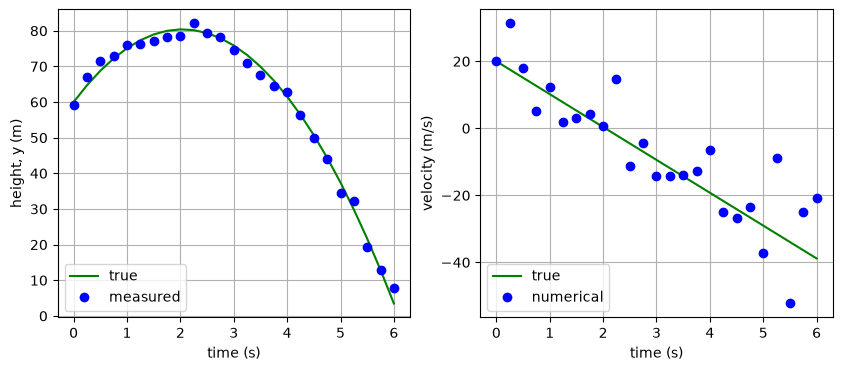

In [95]:
y0 = 60  # initial height, m
v0 = 20  # initial velocity, m/s (positive = upward)
g = -9.8067  # gravitational acceleration, m/s^2
Ts = 0.25  # sampling period, s

t = np.arange(25) * Ts  # 25 sample times: 0, 0.25, ..., 6 s

# Simulated measurement noise. A fixed seed makes everyone get the same data.
rng = np.random.default_rng(20)
noise = rng.normal(0, 2, len(t))  # mean 0, standard deviation 2 m (variance 4 m^2)

# true height and velocity from the equations of motion
y_true = 1 / 2 * g * t**2 + v0 * t + y0 #### THIS IS AN ARRAY???!?!!!?????
v_true = g * t + v0                     #### Did not know numpy could do that 

# observations (measurements): the sensor only measures the height, with noise
z = y_true + noise

# numerical velocity (backward difference): the naive way to get velocity from positions.
# The first value is set to the true v0 because there is no earlier sample.
v_numeric = np.append(v0, np.diff(z) / Ts)

# Plot the height (left) and velocity (right).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(t, y_true, "g", label="true")
ax1.plot(t, z, "bo", label="measured")
ax1.set_xlabel("time (s)")
ax1.set_ylabel("height, y (m)")
ax1.grid(True)
ax1.legend(loc="lower left")

ax2.plot(t, v_true, "g", label="true")
ax2.plot(t, v_numeric, "bo", label="numerical")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("velocity (m/s)")
ax2.grid(True)
ax2.legend(loc="lower left")
plt.show()

The equation of motion of a falling body in discrete time is given by

$$\begin{bmatrix} y_{k} \\ v_{k}\end{bmatrix} =\begin{bmatrix} 1 & T_s \\ 0 & 1\end{bmatrix} \begin{bmatrix} y_{k-1} \\ v_{k-1}\end{bmatrix} + \begin{bmatrix} T_s^2/2 \\ T_s\end{bmatrix} g + \mathbf{w}_k,$$

where $\mathbf{w}_k \sim \mathcal{N}(\mathbf{0}, Q)$ is the process noise. Since we measure the position of the body, the sensor equation is

$$z_{k} =\begin{bmatrix} 1 & 0 \end{bmatrix} \begin{bmatrix} y_{k} \\ v_{k}\end{bmatrix} + v_k,$$

where $v_k \sim \mathcal{N}(0, R)$ is the measurement noise, with $R = 4~\text{m}^2$.

**2a.** Complete `run_kalman_filter` below. You will use it for the rest of this project. Then choose the initial state estimate `x_init` and its covariance `P_init`.

In [96]:
def run_kalman_filter(A, B, C, Q, R, x_init, P_init, measurements, u):
    """Run a Kalman filter over a sequence of measurements.

    Args:
        A, B, C, Q, R: system matrices (see KalmanFilter)
        x_init, P_init: initial state estimate (n x 1) and covariance (n x n)
        measurements: sequence of N measurements, each a k x 1 array
        u: input (m x 1), the same at every step

    Returns:
        xhats: N x n array of state estimates
        state_covs: N x n x n array of state covariances P(k|k)
        state_pred_covs: N x n x n array of predicted state covariances P(k|k-1)
    """
    # TODO: create a KalmanFilter, set its initial values, and call update for every measurement
    # The following lines are placeholders to prevent run-time errors
    n = A.shape[0]  # number of states
    N = len(measurements)  # number of time steps
    k = KalmanFilter(A,B,C,Q,R)
    k.set_init_values(x_init, P_init)

    xhats = np.zeros((N,n))
    state_covs = np.zeros((N,n,n))
    state_pred_covs = np.zeros((N, n, n))

     # have to initialize to not have the measurement array be off by one 


    xhats[0] = x_init[:, 0]

    state_covs[0] = P_init

    for i in range(1, len(measurements)):
        measurement = measurements[i]
        xhat, P, Ppred, KGain = k.update(measurement, u)
        for j in range (n):
            xhats[i][j] = xhat[j][0] #xhats is measurements x states and xhat is n x 1 so need to iterate both
        state_covs[i] = P

    return xhats, state_covs, state_pred_covs
        



    

In [97]:
# State x = [height, velocity]^T; input u = gravitational acceleration; measurement z = height.
A = np.array([[1, Ts], [0, 1]])  # height += Ts * velocity; velocity stays the same
B = np.array([[Ts**2 / 2], [Ts]])  # effect of the acceleration g over one sampling period
C = np.array([[1, 0]])  # we measure only the height
u = np.array([[g]])  # the input is the gravitational acceleration (1 x 1)
R = np.array([[4]])  # measurement noise variance: standard deviation 2 m, so R = 2^2 m^2

# Each measurement must be a k x 1 array (here 1 x 1), so wrap each number in [[ ]].
measurements = [np.array([[obs]]) for obs in z]

# TODO: choose the initial state estimate and its covariance
x_init = np.array([[60], 
                    [20]]) # because these are the initial values above 
P_init = np.array([[4,0], [0,0]]) #because we magically know that 20 is the initial velocity and afterwards don't measure velocity at all (so 0 initial variance)



**2b.** Sweep the process noise variance over `q_values = np.logspace(-4, 4, 17)` with $Q = qI$. For each $q$, run the filter and compute the RMSE of the position and velocity estimates. Plot both RMSEs against $q$ on a logarithmic $q$ axis, and add horizontal lines at the RMSE of the position measurements and of the numerical velocity.

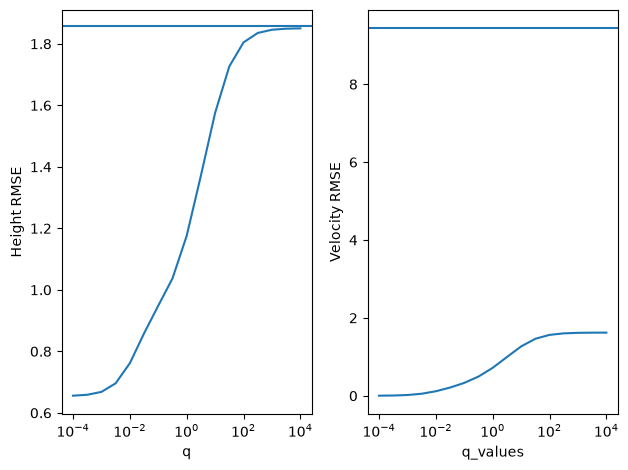

In [98]:
# 17 values of q from 1e-4 to 1e4, evenly spaced on a logarithmic scale
q_values = np.logspace(-4, 4, 17)

heightRMSES = np.zeros(17)
veloRMSES = np.zeros(17)

for i in range(len(q_values)):
    Q = q_values[i]*np.identity(2) #creates 2 x 2 matrix 

    xhats, state_covs, state_pred_covs = run_kalman_filter(A, B, C, Q, R, x_init, P_init, measurements, u)

    estimated_height = xhats[:, 0]
    estimated_velocity = xhats[:,1]

    error = 0
    for j in range(len(estimated_height)):
        error += (estimated_height[j] - y_true[j])**2
    height_rmse = np.sqrt(error) / np.sqrt(len(estimated_velocity))

    error = 0
    for j in range(len(estimated_height)):
        error += (estimated_velocity[j] - v_true[j])**2
    velocity_rmse = np.sqrt(error) / np.sqrt(len(estimated_height))

    heightRMSES[i] = height_rmse
    veloRMSES[i] = velocity_rmse


error = 0
for j in range(len(z)):
    error += (z[j] - y_true[j])**2
measured_height_rmse = np.sqrt(error / len(z))

error = 0
for j in range(len(v_numeric)):
    error += (v_numeric[j] - v_true[j])**2
numerical_velocity_rmse = np.sqrt(error / len(v_numeric))


fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.semilogx(q_values, heightRMSES)
ax1.axhline(measured_height_rmse)
ax1.set_xlabel("q")
ax1.set_ylabel("Height RMSE")

ax2.semilogx(q_values, veloRMSES)
ax2.axhline(numerical_velocity_rmse)
ax2.set_xlabel("q_values")
ax2.set_ylabel("Velocity RMSE")

plt.tight_layout()
plt.show()

# TODO: sweep q and plot the RMSEs

**2c ✍️** Explain both ends of your plot. What does the filter do when $q$ is tiny, and when $q$ is huge? Why do the RMSEs approach those of the measurements and the numerical velocity as $q$ grows?

✍️ *Your answer here.*

When Q is tiny, the error in heigh is minimal because we have extremely accurate sytem dynamics. When our Q is much larger than R, we essentially only use the measurements because when Q approaches infinity its contribution gets infinitely small. Since Q and R function sort of like resistors in parallel, however, we never get larger than one or the other error wise since even a massive Q will slightly reduce overall uncertainty. 

**2d ✍️** Repeat the sweep, but this time with `P_init = Q`: the filter is as confident in its initial guess as it is in its model. What happens at small $q$, and why?

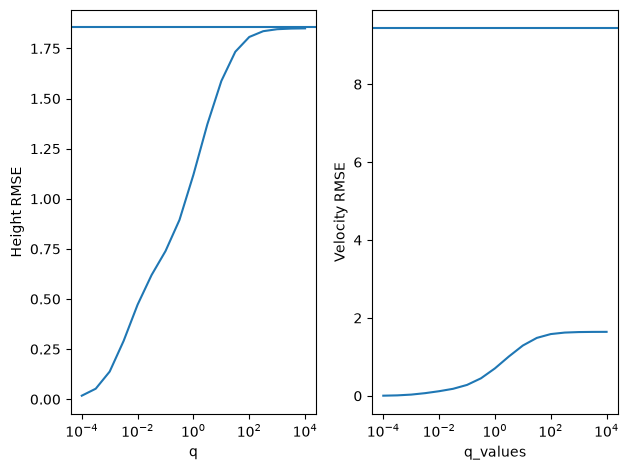

In [99]:
# TODO: repeat the sweep with P_init = Q


heightRMSES = np.zeros(17)
veloRMSES = np.zeros(17)

for i in range(len(q_values)):
    Q = q_values[i]*np.identity(2)
    P_init = q_values[i]*np.identity(2)

    xhats, state_covs, state_pred_covs = run_kalman_filter(A, B, C, Q, R, x_init, P_init, measurements, u)

    estimated_height = xhats[:, 0]
    estimated_velocity = xhats[:,1]

    error = 0
    for j in range(len(estimated_height)):
        error += (estimated_height[j] - y_true[j])**2
    height_rmse = np.sqrt(error) / np.sqrt(len(estimated_velocity))

    error = 0
    for j in range(len(estimated_height)):
        error += (estimated_velocity[j] - v_true[j])**2
    velocity_rmse = np.sqrt(error) / np.sqrt(len(estimated_height))

    heightRMSES[i] = height_rmse
    veloRMSES[i] = velocity_rmse

error = 0
for j in range(len(z)):
    error += (z[j] - y_true[j])**2
measured_height_rmse = np.sqrt(error / len(z))

error = 0
for j in range(len(v_numeric)):
    error += (v_numeric[j] - v_true[j])**2
numerical_velocity_rmse = np.sqrt(error / len(v_numeric))


fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.semilogx(q_values, heightRMSES)
ax1.axhline(measured_height_rmse)
ax1.set_xlabel("q")
ax1.set_ylabel("Height RMSE")

ax2.semilogx(q_values, veloRMSES)
ax2.axhline(numerical_velocity_rmse)
ax2.set_xlabel("q_values")
ax2.set_ylabel("Velocity RMSE")

plt.tight_layout()
plt.show()

✍️ *Your answer here.*

At small Q, P is small as well, which means we are almost completely certain in our first guess and because we lean towards Q for each subsequent guess, our error stays minimal at small Q. 

**2e.** Choose a value of $q$ and plot the height and velocity versus time (true, measured or numerical, and estimated). Submit the plots on Gradescope.

Text(0, 0.5, 'Velocity ')

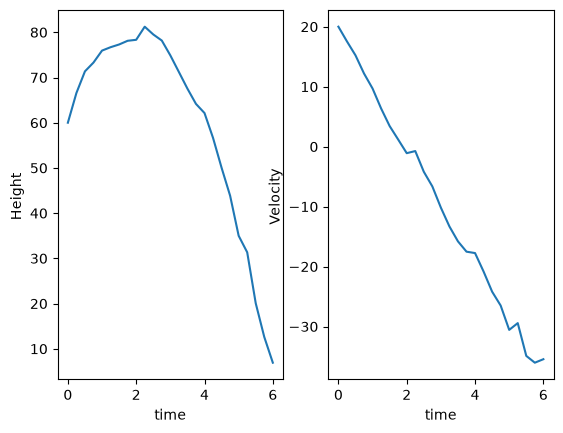

In [100]:
q = 10  # your choice

Q =q*np.identity(2)

P_init = np.array([[4,0], [0,0]])

xhats, state_covs, state_pred_covs = run_kalman_filter(A, B, C, Q, R, x_init, P_init, measurements, u)

estimated_height = xhats[:, 0]
estimated_velocity = xhats[:,1]

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(t, estimated_height)

ax1.set_xlabel("time")
ax1.set_ylabel("Height ")

ax2.plot(t, estimated_velocity)
ax2.set_xlabel("time")
ax2.set_ylabel("Velocity ")

# TODO: run the filter and plot the results

## Deliverable 3
Consider the following ground target tracking problem that we discussed in class.

Dimension of z: (2, 180)


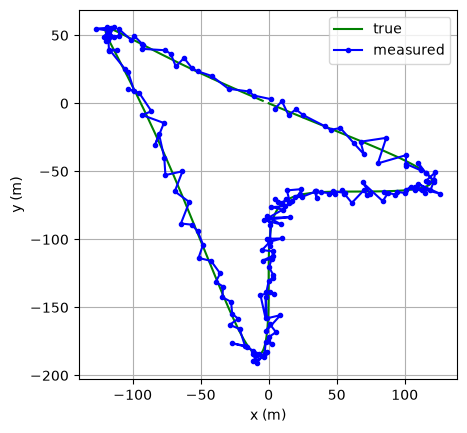

[[ 0.00000000e+00  8.39228633e+00  1.67383825e+01  2.49925561e+01
   3.31099833e+01  4.10471856e+01  4.87624466e+01  5.62162020e+01
   6.33713978e+01  7.01938114e+01  7.66523315e+01  8.27191944e+01
   8.83701727e+01  9.35847163e+01  9.83460441e+01  1.02641188e+02
   1.06460987e+02  1.09800040e+02  1.12656614e+02  1.15032506e+02
   1.16932883e+02  1.18366077e+02  1.19343363e+02  1.19878706e+02
   1.19988496e+02  1.19691273e+02  1.19007435e+02  1.17958953e+02
   1.16569079e+02  1.14862063e+02  1.12862879e+02  1.10596960e+02
   1.08089948e+02  1.05367464e+02  1.02454891e+02  9.93771800e+01
   9.61586768e+01  9.28229682e+01  8.93927501e+01  8.58897167e+01
   8.23344696e+01  7.87464464e+01  7.51438683e+01  7.15437041e+01
   6.79616507e+01  6.44121274e+01  6.09082841e+01  5.74620199e+01
   5.40840116e+01  5.07837512e+01  4.75695899e+01  4.44487871e+01
   4.14275644e+01  3.85111620e+01  3.57038976e+01  3.30092256e+01
   3.04297967e+01  2.79675167e+01  2.56236040e+01  2.33986456e+01
   2.12926

In [101]:
speed = 4.2  # m/s
radius = 120  # m
Ts = 1  # sampling period, s
time = np.arange(0, 180, Ts)  # 180 samples, one per second
omega = speed / radius  # angular speed, rad/s

# True path of the target. The extra sin/cos terms inside make the path wind instead of
# following a plain circle; subtracting cos(1) makes it start at y = 0.
x = np.sin(omega * time + np.sin(omega * time)) * radius
y = (np.cos(omega * time + np.cos(omega * time)) - np.cos(1)) * radius
path = np.vstack((x, y))  # 2 x 180 array: row 0 is x, row 1 is y

# Simulated position measurements. A fixed seed makes everyone get the same data.
rng = np.random.default_rng(17)
# z is a 2 x 180 array of noisy position measurements (standard deviation 4 m)
z = path + rng.normal(0, 4, path.shape)
print(f"Dimension of z: {z.shape}")

# Plot the true path and the measurements.
fig, ax = plt.subplots()
ax.plot(path[0, :], path[1, :], "g", label="true")
ax.plot(z[0, :], z[1, :], "bo-", markersize=3, label="measured")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")  # same scale on both axes, so the path isn't distorted
ax.grid(True)
ax.legend()
plt.show()

print(path)

The equation of motion of the ground target in discrete time is given by

$$\begin{bmatrix} x_{k+1} \\ y_{k+1} \\ \dot{x}_{k+1} \\ \dot{y}_{k+1}\end{bmatrix} =\begin{bmatrix} 1 & 0 & T_s & 0 \\ 0 & 1 &0 & T_s \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x_{k} \\ y_{k} \\ \dot{x}_{k} \\ \dot{y}_{k} \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \\ a_{x,k} \\ a_{y,k} \end{bmatrix},$$

where $a_{x,k}$ and $a_{y,k}$ are zero-mean Gaussian random noises representing the system uncertainty (unknown changes in velocity). There is no control input.

Since we measure the position of the target, the sensor equation is

$$z_{k} =\begin{bmatrix} x_{k} \\ y_{k} \end{bmatrix} + \mathbf{v}_k,$$

where $\mathbf{v}_k \sim \mathcal{N}(\mathbf{0}, \sigma_v^2 I)$ is zero-mean Gaussian measurement noise. The position sensor has a standard deviation of $\sigma_v = 4$ m in each direction.

Equivalently, it can be written in state-space form as follows.

$$z_{k} =\begin{bmatrix} 1 & 0 & 0 & 0 \\  0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} x_{k} \\ y_{k} \\ \dot{x}_{k} \\ \dot{y}_{k} \end{bmatrix} + \begin{bmatrix} v_{x, k} \\ v_{y, k} \end{bmatrix}$$

**3a.** Construct $A$, $B$, $C$, $R$ (from the sensor specification), `x_init`, and `P_init` for the ground target. Use process noise only in the velocity states: $Q = \mathrm{diag}(0, 0, q, q)$.

In [102]:
# figure out initial conditions: 


print(x[0])
print(y[0])

pos0x = x[0]
pos0y = y[0]

# naive initial velocity calculation (guess):
v0x = (x[1]-x[0]) / Ts
v0y = (y[1]-y[0]) / Ts
print( (x[1]-x[0]) / Ts) 
print( (y[1]-y[0]) / Ts)

0.0
0.0
8.39228633269868
-3.5099828461234406


In [103]:
Ts = 1  # sampling period, s

# TODO: construct the system matrices, R, and the initial values
A = np.array([[1, 0, Ts, 0],  #4x4 for 4 states (xpos, xvel, ypox, yvel) x 4 states
              [0,1,0,Ts],
              [0,0,1,0],
              [0,0,0,1]]) 
B = np.array([[0],           #4x1 for 4 states x 1 input (there is no input so we represent )
              [0],
              [0],
              [0]])
C = np.array([[1,0,0,0],
              [0,1,0,0]]) #measuring x direction position and y direction position, but not he velocity in either direction
                            #taking two measurements against 4 states so 2 x 4
R = np.array([[16, 0], 
              [0, 16]])      # standard deviation of 4 creates a variance of 16 need 2x2 because we're measuring 2 things k x k 
x_init = np.array([[pos0x],     # n x 1 4 states 
                    [pos0y],
                    [v0x],
                    [v0y]])
P_init = np.array([[16, 0, 0, 0], # n x n state covariance matrix 
                    [0,16,0,0],
                    [0,0,0,0],
                    [0,0,0,0]])

u = np.zeros((1, 1))  # there is no control input

# z is a 2 x 180 array. z.T is 180 x 2, so each obs is one [x, y] measurement,
# which is reshaped into the 2 x 1 array the filter expects.
measurements = [obs.reshape(2, 1) for obs in z.T]

**3b.** Sweep $q$ over `np.logspace(-4, 4, 17)` again. Plot the RMSE of the $x$ and $y$ position estimates against $q$, with horizontal lines at the RMSE of the measurements.

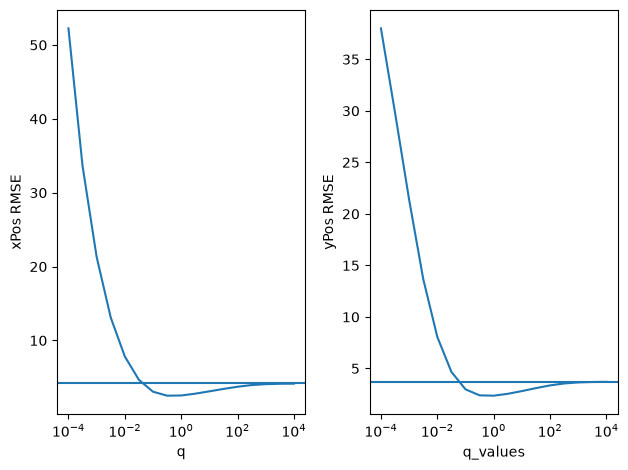

In [ ]:
# 17 values of q from 1e-4 to 1e4, evenly spaced on a logarithmic scale
q_values = np.logspace(-4, 4, 17)

Q = np.array([[0, 0, 0, 0],      #4 states in the process so need 4x4 matrix to get the process uncertainty generated by each of the 4 states updating
                    [0,0,0,0],
                    [0,0,q,0],
                    [0,0,0,q]])


xRMSES = np.zeros(17)
yRMSES = np.zeros(17)

for i in range(len(q_values)): #len(q_values)
    Q = q_values[i]*np.diag([0,0,1,1])
    xhats, state_covs, state_pred_covs = run_kalman_filter(A, B, C, Q, R, x_init, P_init, measurements, u)

    estimated_heightX = xhats[:, 0]
    estimated_heightY = xhats[:, 1]

    error = 0
    for j in range(len(estimated_heightX)):
        error += (estimated_heightX[j] - path[0][j])**2
    x_rmse = np.sqrt(error) / np.sqrt(len(estimated_heightX))

    error = 0
    for j in range(len(estimated_heightY)):
        error += (estimated_heightY[j] - path[1][j])**2
    y_rmse = np.sqrt(error) / np.sqrt(len(estimated_heightY))

    xRMSES[i] = x_rmse
    yRMSES[i] = y_rmse


error = 0
for j in range(len(z[0])): #180 measurements 
    error += (z[0][j] - path[0][j])**2
measured_x_rmse = np.sqrt(error / len(z[0]))

error = 0
for j in range(len(z[0])):
    error += (z[1][j] - path[1][j])**2
measured_y_rmse = np.sqrt(error / len(z[1]))


fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.semilogx(q_values, xRMSES)
ax1.axhline(measured_x_rmse)
ax1.set_xlabel("q")
ax1.set_ylabel("xPos RMSE")

ax2.semilogx(q_values, yRMSES)
ax2.axhline(measured_y_rmse)
ax2.set_xlabel("q_values")
ax2.set_ylabel("yPos RMSE")

plt.tight_layout()
plt.show()

# TODO: sweep q and plot the RMSEs






**3c ✍️** For the falling body, a tiny $q$ worked well. For the ground target, it is much worse than the raw measurements. Why? What does this tell you about how to choose $Q$?

We should choose Q based on how well the system dynamics reflect reality. Because we're only using process noise for velocity, and we're not taking measurements of it, then if the model is wrong, we really weight system dynamics too heavily. But, if we don't weight it at all, then we're doing no better than if we just had the measurements. Probably leading to the optimal dip in the middle. 

**3d.** Choose a value of $q$, run the filter, and plot the true, measured, and estimated trajectories. Report the RMSE of the $x$ and $y$ position estimates. Name the results `xhats`, `state_covs`, and `state_pred_covs`; Deliverable 4 uses them. Submit the plot on Gradescope.

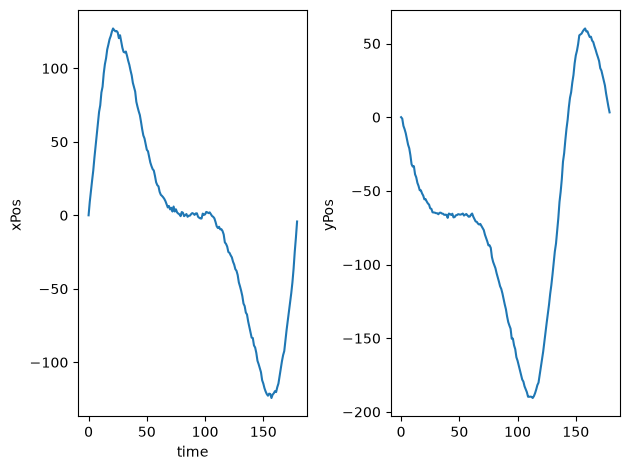

In [106]:
q = 1  # your choice

# 17 values of q from 1e-4 to 1e4, evenly spaced on a logarithmic scale
q = 0.1

Q = np.array([[0, 0, 0, 0],      #4 states in the process so need 4x4 matrix to get the process uncertainty generated by each of the 4 states updating
                    [0,0,0,0],
                    [0,0,q,0],
                    [0,0,0,q]])




Q = q*np.diag([0,0,1,1])
xhats, state_covs, state_pred_covs = run_kalman_filter(A, B, C, Q, R, x_init, P_init, measurements, u)

estimated_heightX = xhats[:, 0]
estimated_heightY = xhats[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(time, estimated_heightX)
ax1.set_xlabel("time")
ax1.set_ylabel("xPos ")

ax2.plot(time, estimated_heightY)
ax2.set_xlabel("")
ax2.set_ylabel("yPos ")

plt.tight_layout()
plt.show()





# TODO: run the filter, report the RMSEs, and plot the trajectories

## Deliverable 4

Each step of a Kalman filter combines two sources of information: the **prediction** from the model and the **measurement** from the sensor. In this deliverable, you will visualize one step of the ground-target filter from Deliverable 3.

The function below draws the confidence ellipse of a 2-D Gaussian distribution with a given mean and covariance. With `n_std=1`, the ellipse marks one standard deviation from the mean.

In [108]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


def confidence_ellipse(mean_x, mean_y, cov, ax, n_std=1.0, facecolor="none", **kwargs):
    """Draw the confidence ellipse of a 2-D Gaussian distribution.

    Args:
        mean_x, mean_y: center of the ellipse
        cov: 2 x 2 covariance matrix
        ax: matplotlib Axes to draw on
        n_std: number of standard deviations that sets the size of the ellipse
        **kwargs: passed to matplotlib.patches.Ellipse (e.g., edgecolor)

    Returns:
        The Ellipse patch that was added to ax.

    Based on https://carstenschelp.github.io/2018/09/14/Plot_Confidence_Ellipse_001.html
    """
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])  # correlation coefficient
    # Ellipse of the normalized (unit-variance) distribution, before scaling
    radius_x = np.sqrt(1 + pearson)
    radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=2 * radius_x, height=2 * radius_y, facecolor=facecolor, **kwargs)

    # Rotate by 45 degrees, scale by the standard deviations, and move to the mean.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transform = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transform + ax.transData)
    return ax.add_patch(ellipse)


**TODO**: Pick time step `k = 60`. On one plot, draw the position (the first two states) and its 1-σ confidence ellipse for:

1. the estimate at step $k-1$: $\hat{x}_{k-1|k-1}$ with $P_{k-1|k-1}$,
2. the prediction: $\hat{x}_{k|k-1}$ with $P_{k|k-1}$,
3. the measurement: $z_k$ with $R$,
4. the updated estimate: $\hat{x}_{k|k}$ with $P_{k|k}$.

Also mark the true position at step $k$. Submit the plot on Gradescope.

C:\Users\C27Dexter.James\AppData\Local\Temp\ipykernel_27124\3855817465.py:20: RuntimeWarning: invalid value encountered in scalar divide
  pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])  # correlation coefficient


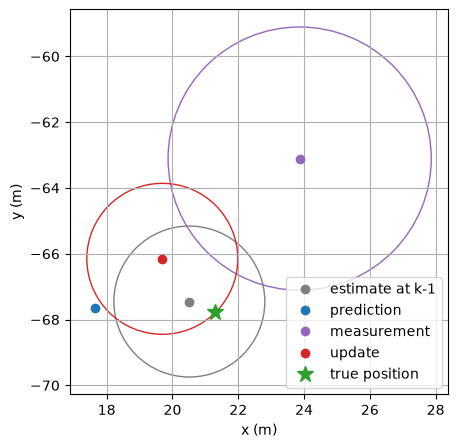

position variance (x) of the prediction: 0.0
position variance (x) of the measurement: 16
position variance (x) of the update: 5.26


In [109]:
# You don't have to modify this code. 
# You need to generate a figure and submit it on Gradescope.
# It is still your responsibility to verify that the figure is correct.

k = 60  # time step to visualize

x_prev = xhats[k - 1]  # estimate at step k-1 (all 4 states) xk-1|k-1
x_pred = A @ x_prev + (B @ u).ravel()  # prediction for step k (the filter doesn't store it)
x_upd = xhats[k]  # updated estimate at step k


# Only the position is plotted, so take the first two states ([:2]) and the top-left
# 2 x 2 block of each covariance ([:2, :2]).
steps = [
    # (label, position, 2 x 2 position covariance, color)
    ("estimate at k-1", x_prev[:2], state_covs[k - 1][:2, :2], "tab:gray"),
    ("prediction", x_pred[:2], state_pred_covs[k][:2, :2], "tab:blue"),
    ("measurement", z[:, k], R, "tab:purple"),
    ("update", x_upd[:2], state_covs[k][:2, :2], "tab:red"),
]

fig, ax = plt.subplots(figsize=(7, 5))
for label, pos, cov, color in steps:
    ax.plot(pos[0], pos[1], "o", color=color, label=label)  # the point
    confidence_ellipse(pos[0], pos[1], cov, ax, n_std=1, edgecolor=color)  # its 1-sigma ellipse
ax.plot(path[0, k], path[1, k], "*", color="tab:green", markersize=12, label="true position")

ax.set_aspect("equal")  # same scale on both axes, so circles look like circles
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.grid(True)
ax.legend()
plt.show()

print("position variance (x) of the prediction:", round(state_pred_covs[k][0, 0], 2))
print("position variance (x) of the measurement:", R[0, 0])
print("position variance (x) of the update:", round(state_covs[k][0, 0], 2))

**TODO**: Answer the following in Gradescope.

1. Where does the updated estimate lie relative to the prediction and the measurement? Why?
2. Compare the sizes of the prediction, measurement, and update ellipses. Why is the update ellipse the smallest?
3. Why is the prediction ellipse larger than the ellipse at step $k-1$?

## ✅ Check-off

After you submit, you will have a short (about 2 minutes) check-off with your instructor. You will be asked to explain your work without notes, for example:

- how each line of your `update` function corresponds to the filter equations,
- the shapes of $A$, $B$, $C$, $Q$, $R$, and $K$ in Deliverables 2 and 3,
- what your $q$ sweeps show, and why the two sweeps look different.

Be ready to explain every line of code you submit.